In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import polars as pl
import pyarrow
import gc
from itertools import combinations
import matplotlib.pyplot as plt
sys.path.append(str(Path("..")))
# Backtest dataset construction - universe tradable daily 
from src.ingest.ingest_backtest import build_backtest_warmup_parquets
from src.universe.pair_universe import (build_universe_metadata_from_symbol_parquets,apply_sector_fixes,generate_candidate_pairs,
                                        build_daily_tradable_universe,)

Within same-sector Nasdaq-100 stocks, larger-cap or more liquid names may incorporate information earlier. If this is true, lagged returns of the leader should have explanatory power over future returns of the follower.



In [2]:
BACKTEST_DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")

SECTOR_FIXES = {"ASML": "SEMICONDUCTORS & RELATED DEVICES",
                "CCEP": "BEVERAGES",
                "PDD": "RETAIL-CATALOG & MAIL-ORDER HOUSES",
                "TRI": "SERVICES-BUSINESS SERVICES, NEC",}

# 1. Build Universe Metadata
universe_df = build_universe_metadata_from_symbol_parquets(BACKTEST_DATA_DIR)
universe_df = apply_sector_fixes(universe_df,SECTOR_FIXES)
# 2. Generate Same-Sector Candidate Pairs
df_candidate_pairs = generate_candidate_pairs(universe_df)

# example of how the workflow should works: 
- The main idea is: 
  1. compute the log returns of three assets
  2. compute cross correlation from asset A to Asset B 'corr_forward' ,AND Asset B to Asset A 'corr_forward,corr_reverse' by lags [1,5,10,15,30] min interval 
  3. "lead_score" = "A_to_B" - "B_to_A"

In [ ]:
adi = pd.read_parquet("../data/backtest_1min_with_warmup_by_symbol/ADI_backtest_1min_warmup.parquet")
amat = pd.read_parquet("../data/backtest_1min_with_warmup_by_symbol/AMAT_backtest_1min_warmup.parquet")
amd = pd.read_parquet("../data/backtest_1min_with_warmup_by_symbol/AMD_backtest_1min_warmup.parquet")

# test
def add_log_return(df):
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    return df
dfs = { 'adi' : adi,'amat' : amat, 'amd': amd}
for symbol, df in dfs.items():
    dfs[symbol] = add_log_return(df)
# two candidate merge 
adi_amat = pd.merge(adi[['date', 'log_return']], amat[['date', 'log_return']], on='date', suffixes=('adi', 'amat'))
# adi & amd
adi_amd = pd.merge(adi[['date', 'log_return']], amd[['date', 'log_return']], on='date', suffixes=('adi', 'amd'))
pairs = {"ADI_AMAT": adi_amat,"ADI_AMD": adi_amd}
lags = [1,5,15,30]
results = []
for pair_name, df in pairs.items():
    col1 = [c for c in df.columns if "adi" in c][0]
    col2 = [c for c in df.columns if col1 != c and "log_return" in c][0]
    for lag in lags:
        corr_forward = (df[col1].corr(df[col2].shift(-lag)))
        corr_reverse = (df[col2].corr(df[col1].shift(-lag)))
        results.append([pair_name,lag,corr_forward,corr_reverse])
results = pd.DataFrame(results,columns=["pair","lag","A_to_B","B_to_A"])
results["lead_score"] = (results["A_to_B"]- results["B_to_A"])
results

,pair,lag,A_to_B,B_to_A,lead_score
0,ADI_AMAT,1,0.004685,0.020605,-0.015920
1,ADI_AMAT,5,-0.003520,-0.003696,0.000176
2,ADI_AMAT,15,0.007188,0.010060,-0.002873
3,ADI_AMAT,30,0.000296,0.002476,-0.002180
4,ADI_AMD,1,0.005376,0.019947,-0.014571
5,ADI_AMD,5,-0.000682,-0.002218,0.001536
6,ADI_AMD,15,0.000774,0.003551,-0.002777
7,ADI_AMD,30,-0.000906,0.003449,-0.004355


In [ ]:
from pathlib import Path

DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")
LAGS = [1, 5, 15, 30]

def load_symbol_returns(symbol, data_dir=DATA_DIR):
    path = data_dir / f"{symbol}_backtest_1min_warmup.parquet"
    df = pd.read_parquet(path)
    df = df[["date", "close"]].copy()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    return df[["date", "log_return"]].dropna()


def compute_pair_lead_lag(stock_a, stock_b, sector=None, lags=LAGS):
    a = load_symbol_returns(stock_a).rename(columns={"log_return": "r_a"})
    b = load_symbol_returns(stock_b).rename(columns={"log_return": "r_b"})
    pair_df = pd.merge(a, b, on="date", how="inner").dropna()
    rows = []
    for lag in lags:
        a_to_b = pair_df["r_a"].corr(pair_df["r_b"].shift(-lag))
        b_to_a = pair_df["r_b"].corr(pair_df["r_a"].shift(-lag))
        lead_score = a_to_b - b_to_a
        rows.append({
            "stock_a": stock_a,
            "stock_b": stock_b,
            "sector": sector,
            "lag": lag,
            "A_to_B": a_to_b,
            "B_to_A": b_to_a,
            "lead_score": lead_score,
            "abs_lead_score": abs(lead_score),
            "empirical_leader": stock_a if lead_score > 0 else stock_b,
            "empirical_follower": stock_b if lead_score > 0 else stock_a,
            "n_obs": len(pair_df)
        })
    return pd.DataFrame(rows)

all_results = []

for _, row in df_candidate_pairs.iterrows():
    pair_result = compute_pair_lead_lag(stock_a=row["stock_a"], stock_b=row["stock_b"], sector=row["sector"], lags=LAGS)
    all_results.append(pair_result)

lead_lag_results = pd.concat(all_results, ignore_index=True)
lead_lag_clean = lead_lag_results.query("n_obs >= 10000").copy()
lead_lag_clean.sort_values("abs_lead_score", ascending=False).head(20)

,stock_a,stock_b,sector,lag,A_to_B,B_to_A,lead_score,abs_lead_score,empirical_leader,empirical_follower,n_obs
246,AVGO,MPWR,SEMICONDUCTORS & RELATED DEVICES,15,0.000449,-0.086163,0.086613,0.086613,AVGO,MPWR,12991
408,MELI,PYPL,"SERVICES-BUSINESS SERVICES, NEC",1,0.005223,0.065919,-0.060696,0.060696,PYPL,MELI,477455
708,MSFT,SNPS,SERVICES-PREPACKAGED SOFTWARE,1,0.054634,0.000429,0.054206,0.054206,MSFT,SNPS,477455
334,MPWR,NXPI,SEMICONDUCTORS & RELATED DEVICES,15,0.042501,-0.008463,0.050965,0.050965,MPWR,NXPI,12991
138,AMAT,MPWR,SEMICONDUCTORS & RELATED DEVICES,15,0.011290,-0.039127,0.050417,0.050417,AMAT,MPWR,12991
676,INTU,MSFT,SERVICES-PREPACKAGED SOFTWARE,1,-0.001523,0.048300,-0.049824,0.049824,MSFT,INTU,477455
54,INSM,VRTX,PHARMACEUTICAL PREPARATIONS,15,0.045382,-0.003079,0.048461,0.048461,INSM,VRTX,12991
224,ASML,NVDA,SEMICONDUCTORS & RELATED DEVICES,1,0.003750,0.049794,-0.046044,0.046044,NVDA,ASML,477455
160,AMD,ASML,SEMICONDUCTORS & RELATED DEVICES,1,0.046654,0.002959,0.043696,0.043696,AMD,ASML,477455
16,CHTR,CMCSA,CABLE & OTHER PAY TELEVISION SERVICES,1,0.008401,0.051989,-0.043587,0.043587,CMCSA,CHTR,477455


In [11]:
lead_lag_clean.groupby(["sector","empirical_leader"]).size()

sector                                                empirical_leader
BEVERAGES                                             CCEP                 3
                                                      KDP                  5
                                                      PEP                  4
BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)       AMGN                 2
                                                      GILD                 2
CABLE & OTHER PAY TELEVISION SERVICES                 CHTR                 2
                                                      CMCSA                2
COMPUTER PERIPHERAL EQUIPMENT, NEC                    FTNT                 2
                                                      PANW                 2
COMPUTER STORAGE DEVICES                              STX                  2
                                                      WDC                  2
ELECTRIC & OTHER SERVICES COMBINED                    EXC                  2
     

In [ ]:
leader_counts = (lead_lag_clean["empirical_leader"].value_counts().reset_index())
leader_counts.columns = ["symbol", "count"]

# 1. Crear el gráfico de barras ordenado de mayor a menor
fig = px.bar(
    leader_counts,
    x="symbol",
    y="count",
    title="Frecuencia de Liderazgo por Acción (Efecto Lead-Lag)",
    labels={"symbol": "Acción (Ticker)", "count": "Veces como Líder"},
    text_auto=True,  # Muestra el número exacto sobre cada barra
    color="count",  # Aplica un degradado de color según el conteo
    color_continuous_scale="Viridis",
)

# 2. Mejorar el diseño para que sea fácil de leer
fig.update_layout(
    xaxis_tickangle=-45,  # Inclina los tickers si son muchos (tienes 95)
    xaxis={"categoryorder": "total descending"},  # Asegura el orden descendente
    plot_bgcolor="white",  # Fondo limpio
    height=600,  # Altura ajustable para acomodar los 95 símbolos
)

# 3. Mostrar el gráfico
fig.show()


Sin avanzar más:

La señal parece concentrarse en lag=1 minuto.
La distribución de líderes no parece uniforme.
Aparecen nombres repetidamente (AMD, NVDA, INTC, MSFT, PLTR).
La métrica está produciendo una estructura interpretable, no puro ruido.


--- 
# Validación estadística del efecto lead-lag

In [36]:
msft= pd.read_parquet("../data/backtest_1min_with_warmup_by_symbol/AMD_backtest_1min_warmup.parquet")
snps = pd.read_parquet("../data/backtest_1min_with_warmup_by_symbol/NVDA_backtest_1min_warmup.parquet")

def add_log_return(df):
    # Fórmula correcta: ln( Price_t / Price_t-1 )
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    return df
add_log_return(snps)
add_log_return(msft)
amd_nvda = pd.merge(msft[['date', 'log_return']], snps[['date', 'log_return']], on='date', suffixes=('_msft', '_snps'))
amd_nvda


,date,log_return_msft,log_return_snps
0,2021-06-01 09:15:00,NaN,NaN
1,2021-06-01 09:16:00,-0.000370,-0.000153
2,2021-06-01 09:17:00,0.000123,0.000000
3,2021-06-01 09:18:00,0.000246,-0.000381
4,2021-06-01 09:19:00,0.000000,-0.000387
...,...,...,...
477451,2026-02-04 15:56:00,-0.001586,-0.000946
477452,2026-02-04 15:57:00,-0.003977,0.000287
477453,2026-02-04 15:58:00,-0.002643,0.001175
477454,2026-02-04 15:59:00,-0.000249,-0.002380


In [ ]:
def lead_score(x, y, lag=1):
    a_to_b = x.corr(y.shift(-lag))
    b_to_a = y.corr(x.shift(-lag))
    return a_to_b - b_to_a

def permutation_test_lead_score(x,y,lag=1,n_permutations=1000,random_state=42):
    rng = np.random.default_rng(random_state)
    real_score = lead_score(x, y, lag)
    random_scores = []
    y_clean = y.dropna().values
    for _ in range(n_permutations):
        y_perm = rng.permutation(y_clean)
        y_perm = pd.Series(y_perm,index=y.dropna().index)
        score = lead_score( x.loc[y_perm.index],y_perm,lag)
        random_scores.append(score)
    random_scores = np.array(random_scores)
    p_value = np.mean( np.abs(random_scores)>=np.abs(real_score))

    return {"real_score": real_score,"random_mean": random_scores.mean(),"random_std": random_scores.std(),
            "p_value": p_value,"random_scores": random_scores}

result = permutation_test_lead_score(amd_nvda["log_return_msft"],amd_nvda["log_return_snps"],lag=1)
result

{'real_score': np.float64(0.0021254219370133824),
 'random_mean': np.float64(-7.5391717447962e-05),
 'random_std': np.float64(0.002062638069602675),
 'p_value': np.float64(0.274),
 'random_scores': array([-1.49050680e-04,  9.85028445e-04,  9.92420121e-04, -1.61419194e-03,
         2.24718885e-03,  4.57800460e-03, -2.83024129e-04, -1.08426814e-03,
         2.82579664e-03, -2.22318374e-03,  2.13307782e-03, -1.32445827e-03,
         2.03850661e-03, -1.19478779e-03, -1.05027677e-03, -3.58873074e-03,
         5.59167053e-05, -1.87468517e-03, -1.31217980e-03,  6.12621021e-04,
        -5.48977393e-04, -1.26988076e-03,  8.18064793e-04, -1.43082825e-03,
        -2.22579859e-05, -2.42785220e-03, -2.59706548e-03,  2.76190673e-03,
        -1.25535223e-03, -1.63318954e-03,  2.86500196e-03,  1.83295061e-03,
         8.75759004e-04,  1.12937520e-03, -3.11822931e-03,  2.10953801e-03,
        -7.97503387e-04, -2.14091585e-04,  3.54559918e-03,  1.64235055e-05,
        -2.80381448e-03, -6.44624299e-04,  

In [38]:
import plotly.express as px
fig = px.histogram(x=result["random_scores"],nbins=50,title="Permutation Distribution of Lead Score")
fig.add_vline(x=result["real_score"],line_width=3)
fig.show()

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")

def load_symbol_returns(symbol, data_dir=DATA_DIR):
    path = data_dir / f"{symbol}_backtest_1min_warmup.parquet"
    
    df = pd.read_parquet(path)
    df = df[["date", "close"]].copy()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    
    return df[["date", "log_return"]].dropna()


# Cargar retornos solo de los símbolos que aparecen en df_candidate_pairs
symbols = sorted(set(df_candidate_pairs["stock_a"]).union(set(df_candidate_pairs["stock_b"])))

returns_by_symbol = {}

for symbol in symbols:
    returns_by_symbol[symbol] = load_symbol_returns(symbol)

len(returns_by_symbol)

62

In [ ]:
def lead_score(x, y, lag=1):
    a_to_b = x.corr(y.shift(-lag))
    b_to_a = y.corr(x.shift(-lag))
    return a_to_b - b_to_a


def permutation_test_lead_score(x,y,lag=1,n_permutations=1000,random_state=42):
    rng = np.random.default_rng(random_state)
    real_score = lead_score(x, y, lag)
    random_scores = []
    y_clean = y.dropna()
    x_aligned = x.loc[y_clean.index]

    for _ in range(n_permutations):
        y_perm = rng.permutation(y_clean.values)
        y_perm = pd.Series(y_perm,index=y_clean.index)
        score = lead_score(x_aligned, y_perm, lag)
        random_scores.append(score)

    random_scores = np.array(random_scores)

    p_value = np.mean(np.abs(random_scores) >= np.abs(real_score))

    return {"lead_score": real_score,"random_mean": random_scores.mean(),"random_std": random_scores.std(),"p_value": p_value}


MIN_OBS = 10000
N_PERMUTATIONS = 1000
LAG = 1

all_tests = []

for _, row in df_candidate_pairs.iterrows():
    stock_a = row["stock_a"]
    stock_b = row["stock_b"]
    sector = row["sector"]
    a = returns_by_symbol[stock_a].rename(columns={"log_return": "r_a"})
    b = returns_by_symbol[stock_b].rename(columns={"log_return": "r_b"})
    pair_df = pd.merge(a,b,on="date",how="inner").dropna()
    n_obs = len(pair_df)
    if n_obs < MIN_OBS:
        print(f"Skipping {stock_a}-{stock_b}: only {n_obs} observations")
        continue
    test = permutation_test_lead_score(pair_df["r_a"],pair_df["r_b"],lag=LAG,n_permutations=N_PERMUTATIONS,random_state=42)
    lead_score_value = test["lead_score"]
    all_tests.append({"pair": f"{stock_a}-{stock_b}","stock_a": stock_a,
        "stock_b": stock_b,
        "sector": sector,
        "lag": LAG,
        "lead_score": lead_score_value,
        "abs_lead_score": abs(lead_score_value),
        "p_value": test["p_value"],
        "random_mean": test["random_mean"],
        "random_std": test["random_std"],
        "empirical_leader": stock_a if lead_score_value > 0 else stock_b,
        "empirical_follower": stock_b if lead_score_value > 0 else stock_a,
        "n_obs": n_obs
    })

lead_lag_significance = pd.DataFrame(all_tests)

lead_lag_significance.sort_values("p_value").head(20)

Skipping COST-WMT: only 5683 observations
Skipping ADBE-SHOP: only 811 observations
Skipping ADSK-SHOP: only 811 observations
Skipping CDNS-SHOP: only 811 observations
Skipping CRWD-SHOP: only 811 observations
Skipping DDOG-SHOP: only 811 observations
Skipping EA-SHOP: only 811 observations
Skipping INTU-SHOP: only 811 observations
Skipping MSFT-SHOP: only 811 observations
Skipping PLTR-SHOP: only 811 observations
Skipping SHOP-SNPS: only 811 observations
Skipping SHOP-TEAM: only 811 observations
Skipping SHOP-TTWO: only 811 observations


,pair,stock_a,stock_b,sector,lag,lead_score,abs_lead_score,p_value,random_mean,random_std,empirical_leader,empirical_follower,n_obs
0,CCEP-KDP,CCEP,KDP,BEVERAGES,1,-0.017671,0.017671,0.0,-0.000032,0.002375,KDP,CCEP,315461
1,CCEP-PEP,CCEP,PEP,BEVERAGES,1,-0.027135,0.027135,0.0,0.000017,0.002475,PEP,CCEP,315461
2,KDP-PEP,KDP,PEP,BEVERAGES,1,-0.009183,0.009183,0.0,-0.000020,0.002031,PEP,KDP,477455
3,AMGN-GILD,AMGN,GILD,"BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",1,-0.021105,0.021105,0.0,-0.000020,0.001951,GILD,AMGN,477455
4,CHTR-CMCSA,CHTR,CMCSA,CABLE & OTHER PAY TELEVISION SERVICES,1,-0.043587,0.043587,0.0,-0.000013,0.002097,CMCSA,CHTR,477455
14,REGN-VRTX,REGN,VRTX,PHARMACEUTICAL PREPARATIONS,1,-0.031920,0.031920,0.0,0.000036,0.001955,VRTX,REGN,477455
11,ALNY-VRTX,ALNY,VRTX,PHARMACEUTICAL PREPARATIONS,1,-0.026512,0.026512,0.0,-0.000119,0.003241,VRTX,ALNY,172143
8,PCAR-TSLA,PCAR,TSLA,MOTOR VEHICLES & PASSENGER CAR BODIES,1,-0.008360,0.008360,0.0,-0.000024,0.002049,TSLA,PCAR,477455
24,ADI-MU,ADI,MU,SEMICONDUCTORS & RELATED DEVICES,1,-0.014484,0.014484,0.0,-0.000068,0.002054,MU,ADI,477455
25,ADI-NVDA,ADI,NVDA,SEMICONDUCTORS & RELATED DEVICES,1,-0.017401,0.017401,0.0,-0.000070,0.001989,NVDA,ADI,477455


In [ ]:
lead_lag_significance.to_csv('..\data\lead_lag_significance.csv',index = False )

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\avazq\AppData\Local\Temp\ipykernel_2120\896620475.py:1: SyntaxWarning: invalid escape sequence '\d'
  lead_lag_significance.to_csv('..\data\lead_lag_significance.csv',index = False )


In [ ]:
import plotly.express as px

fig = px.scatter(lead_lag_significance,x="abs_lead_score",y="p_value",hover_data=["pair","sector"],title="Lead Score vs Statistical Significance")
fig.add_hline(y=0.05,line_dash="dash")
fig.show()

In [8]:
lead_lag_significance.groupby("empirical_leader").size().sort_values(ascending=False)

empirical_leader
AMD      12
NVDA     11
MSFT     10
PLTR     10
INTC     10
DDOG      9
MRVL      9
MU        8
CRWD      8
EA        7
ADBE      7
AMAT      7
TXN       6
MCHP      5
TEAM      5
PYPL      4
CDNS      4
ADI       4
DASH      3
AVGO      3
TTWO      3
NXPI      2
VRTX      2
CSGP      2
ADP       2
REGN      2
GOOGL     2
INTU      2
INSM      2
PEP       2
ADSK      1
ASML      1
CMCSA     1
GOOG      1
EXC       1
CTSH      1
KDP       1
FTNT      1
GILD      1
PDD       1
TSLA      1
TRI       1
STX       1
WDAY      1
dtype: int64

Hasta ahora encontramos:

- La señal vive principalmente en lag=1.
- Algunos pares no tienen efecto significativo.
- Otros pares sí tienen lead_score muy por encima de lo esperado bajo permutación.
-El líder empírico no necesariamente coincide con una narrativa simple de market cap.
- ADI, por ejemplo, aparece muchas veces como follower frente a AMD, AMAT, INTC, MRVL, MU, NVDA, TXN.

# ¿Qué tan buena era la regla de market cap para identificar al líder?

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")

def get_market_cap(symbol, data_dir=DATA_DIR):
    path = data_dir / f"{symbol}_backtest_1min_warmup.parquet"
    df = pd.read_parquet(path, columns=["market_cap"])
    return df["market_cap"].dropna().iloc[0]


def get_market_cap_leader(stock_a, stock_b):
    market_cap_a = get_market_cap(stock_a)
    market_cap_b = get_market_cap(stock_b)

    if market_cap_a >= market_cap_b:
        return stock_a, stock_b, market_cap_a, market_cap_b
    else:
        return stock_b, stock_a, market_cap_a, market_cap_b
rows = []
for _, row in lead_lag_significance.iterrows():

    stock_a = row["stock_a"]
    stock_b = row["stock_b"]

    market_cap_leader, market_cap_follower, market_cap_a, market_cap_b = get_market_cap_leader(stock_a,stock_b)
    rows.append({
        "pair": row["pair"],
        "stock_a": stock_a,
        "stock_b": stock_b,
        "sector": row["sector"],
        "lag": row["lag"],
        "lead_score": row["lead_score"],
        "abs_lead_score": row["abs_lead_score"],
        "p_value": row["p_value"],
        "empirical_leader": row["empirical_leader"],
        "empirical_follower": row["empirical_follower"],
        "market_cap_leader": market_cap_leader,
        "market_cap_follower": market_cap_follower,
        "market_cap_a": market_cap_a,
        "market_cap_b": market_cap_b,
        "leader_match": row["empirical_leader"] == market_cap_leader,
        "n_obs": row["n_obs"]
    })

leader_comparison = pd.DataFrame(rows)

leader_comparison.head()

,pair,stock_a,stock_b,sector,lag,lead_score,abs_lead_score,p_value,empirical_leader,empirical_follower,market_cap_leader,market_cap_follower,market_cap_a,market_cap_b,leader_match,n_obs
0,CCEP-KDP,CCEP,KDP,BEVERAGES,1,-0.017671,0.017671,0.0,KDP,CCEP,CCEP,KDP,4.254597e+10,3.865169e+10,False,315461
1,CCEP-PEP,CCEP,PEP,BEVERAGES,1,-0.027135,0.027135,0.0,PEP,CCEP,PEP,CCEP,4.254597e+10,2.271097e+11,True,315461
2,KDP-PEP,KDP,PEP,BEVERAGES,1,-0.009183,0.009183,0.0,PEP,KDP,PEP,KDP,3.865169e+10,2.271097e+11,True,477455
3,AMGN-GILD,AMGN,GILD,"BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",1,-0.021105,0.021105,0.0,GILD,AMGN,AMGN,GILD,1.973818e+11,1.814246e+11,False,477455
4,CHTR-CMCSA,CHTR,CMCSA,CABLE & OTHER PAY TELEVISION SERVICES,1,-0.043587,0.043587,0.0,CMCSA,CHTR,CMCSA,CHTR,2.838826e+10,1.097343e+11,True,477455


In [10]:
leader_comparison["leader_match"].mean()

np.float64(0.6045197740112994)

In [11]:
leader_comparison.query("p_value < 0.05")["leader_match"].mean()

np.float64(0.6060606060606061)

In [17]:
empirical_leader = lead_lag_significance.query("p_value < 0.05")
empirical_leader
empirical_leader.to_parquet('../data/empirical_leaders.parquet', index = False)

In [18]:
empirical_leader

,pair,stock_a,stock_b,sector,lag,lead_score,abs_lead_score,p_value,random_mean,random_std,empirical_leader,empirical_follower,n_obs
0,CCEP-KDP,CCEP,KDP,BEVERAGES,1,-0.017671,0.017671,0.000,-0.000032,0.002375,KDP,CCEP,315461
1,CCEP-PEP,CCEP,PEP,BEVERAGES,1,-0.027135,0.027135,0.000,0.000017,0.002475,PEP,CCEP,315461
2,KDP-PEP,KDP,PEP,BEVERAGES,1,-0.009183,0.009183,0.000,-0.000020,0.002031,PEP,KDP,477455
3,AMGN-GILD,AMGN,GILD,"BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",1,-0.021105,0.021105,0.000,-0.000020,0.001951,GILD,AMGN,477455
4,CHTR-CMCSA,CHTR,CMCSA,CABLE & OTHER PAY TELEVISION SERVICES,1,-0.043587,0.043587,0.000,-0.000013,0.002097,CMCSA,CHTR,477455
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,PLTR-TEAM,PLTR,TEAM,SERVICES-PREPACKAGED SOFTWARE,1,0.009728,0.009728,0.017,-0.000208,0.003743,PLTR,TEAM,111649
173,PLTR-TTWO,PLTR,TTWO,SERVICES-PREPACKAGED SOFTWARE,1,0.011172,0.011172,0.011,-0.000031,0.003328,PLTR,TTWO,111649
174,SNPS-TEAM,SNPS,TEAM,SERVICES-PREPACKAGED SOFTWARE,1,-0.022880,0.022880,0.000,-0.000062,0.002053,TEAM,SNPS,477455
175,SNPS-TTWO,SNPS,TTWO,SERVICES-PREPACKAGED SOFTWARE,1,-0.011289,0.011289,0.001,0.000015,0.001976,TTWO,SNPS,477455


Using a lead-lag cross-correlation framework with permutation-based significance testing, we find that market capitalization correctly identifies the empirical leader in approximately 60% of same-sector Nasdaq pairs. This suggests that market cap contains meaningful information regarding information leadership, but fails to capture a substantial fraction of the observed lead-lag structure. Roughly 40% of empirically detected leadership relationships differ from those implied by market capitalization alone.

--- 

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import polars as pl
import pyarrow
import gc
from itertools import combinations
import matplotlib.pyplot as plt
sys.path.append(str(Path("..")))
# Backtest dataset construction - universe tradable daily 
from src.ingest.ingest_backtest import build_backtest_warmup_parquets
from src.universe.pair_universe import (build_universe_metadata_from_symbol_parquets,apply_sector_fixes,generate_candidate_pairs,
                                        build_daily_tradable_universe,)
# strategy engine
from src.backtest.strategy_engine import run_single_day_backtest
from src.backtest.strategy_engine import run_full_backtest

# QQQ benchamrk
from src.backtest.benchmark import build_buy_hold_benchmark_from_raw

In [20]:
"""
Pair Universe Construction - Empirical Lead-Lag Version

Build the daily tradable universe used by the backtest.

Pipeline

1. Read empirically validated lead-lag pairs from empirical_leaders.parquet.
2. Use only pairs that passed the lead-lag statistical validation.
3. Compute rolling 60-day correlations using 1-minute RTH log returns.
4. Shift correlations one trading day forward to avoid look-ahead bias.
5. Rank pairs by rolling correlation for each trading day.
6. Select the Top50 most correlated pairs.
7. Assign leader and follower using the empirical lead-lag relationship:
    - Leader = empirical_leader
    - Follower = empirical_follower

Output
------
Daily tradable universe:

    trading_day
    stock_a
    stock_b
    sector
    rolling_corr_60d
    leader
    follower

Bias Controls
-------------
- Pair universe comes only from statistically validated same-sector pairs.
- Correlations use only information available up to t-1.
- Top50 selection is shifted forward one trading day.
- No future information is used in pair ranking.
- Leader/follower assignment uses the precomputed empirical lead-lag table.

Notes
-----
The resulting universe is the only set of pairs allowed to trade
during each trading day in the backtest engine.
"""


import pandas as pd
import numpy as np
from pathlib import Path
import sys
from itertools import combinations

sys.path.append(str(Path("..")))


def build_universe_metadata_from_symbol_parquets(data_dir):
    records = []

    for file in Path(data_dir).glob("*_backtest_1min_warmup.parquet"):
        df = pd.read_parquet(
            file,
            columns=[
                "symbol",
                "market_cap",
                "sic_description",
                "company_name"
            ]
        )

        records.append({
            "symbol": df["symbol"].iloc[0],
            "market_cap": df["market_cap"].iloc[0],
            "sector": df["sic_description"].iloc[0],
            "company_name": df["company_name"].iloc[0],
        })

    universe_df = (
        pd.DataFrame(records)
        .sort_values("symbol")
        .reset_index(drop=True)
    )

    return universe_df


def apply_sector_fixes(universe_df, sector_fixes):
    universe_df = universe_df.copy()

    for symbol, sector in sector_fixes.items():
        universe_df.loc[
            universe_df["symbol"] == symbol,
            "sector"
        ] = sector

    return universe_df


def generate_candidate_pairs(universe_df):
    assert universe_df["sector"].isna().sum() == 0, "There are missing sectors."

    pair_records = []

    for sector, group in universe_df.groupby("sector"):
        symbols = sorted(group["symbol"].unique())

        for stock_a, stock_b in combinations(symbols, 2):
            pair_records.append({
                "stock_a": stock_a,
                "stock_b": stock_b,
                "sector": sector
            })

    return pd.DataFrame(pair_records)


def load_empirical_leaders(empirical_leaders_path):
    """
    Load statistically validated empirical lead-lag pairs.

    Expected columns:
        stock_a
        stock_b
        sector
        empirical_leader
        empirical_follower
        lead_score
        p_value
        n_obs
    """

    empirical_leaders = pd.read_parquet(empirical_leaders_path).copy()

    required_cols = {
        "stock_a",
        "stock_b",
        "sector",
        "empirical_leader",
        "empirical_follower"
    }

    missing_cols = required_cols - set(empirical_leaders.columns)

    if missing_cols:
        raise ValueError(
            f"empirical_leaders.parquet is missing columns: {missing_cols}"
        )

    empirical_leaders["pair_key"] = empirical_leaders.apply(
        lambda row: tuple(sorted([row["stock_a"], row["stock_b"]])),
        axis=1
    )

    return empirical_leaders


def build_empirical_candidate_pairs(empirical_leaders):
    """
    Build the candidate pair universe directly from empirical_leaders.parquet.

    This replaces the original same-sector candidate pair universe.
    Only statistically validated lead-lag pairs are eligible.
    """

    cols_to_keep = [
        "stock_a",
        "stock_b",
        "sector",
        "empirical_leader",
        "empirical_follower"
    ]

    optional_cols = [
        "lead_score",
        "abs_lead_score",
        "p_value",
        "random_mean",
        "random_std",
        "n_obs"
    ]

    cols_to_keep += [
        col for col in optional_cols
        if col in empirical_leaders.columns
    ]

    empirical_pairs = (
        empirical_leaders[cols_to_keep]
        .drop_duplicates(subset=["stock_a", "stock_b"])
        .reset_index(drop=True)
    )

    return empirical_pairs


def load_symbol_backtest_returns(symbol, data_dir):
    df = pd.read_parquet(
        data_dir / f"{symbol}_backtest_1min_warmup.parquet"
    )

    df = df.sort_values("date").copy()

    # Correlation universe uses RTH only, not SMA warm-up period.
    df = df.loc[
        (df["date"].dt.time >= pd.to_datetime("09:30").time()) &
        (df["date"].dt.time <= pd.to_datetime("16:00").time())
    ].copy()

    df["log_return_1m"] = np.log(df["close"] / df["close"].shift(1))
    df["trading_day"] = df["date"].dt.date

    return df[
        [
            "date",
            "trading_day",
            "symbol",
            "close",
            "log_return_1m"
        ]
    ]


def compute_pair_daily_corr_previous_60d(
    stock_a,
    stock_b,
    data_dir,
    window_size
):
    df_a = load_symbol_backtest_returns(stock_a, data_dir)
    df_b = load_symbol_backtest_returns(stock_b, data_dir)

    df_pair = (
        df_a[["date", "log_return_1m"]]
        .rename(columns={"log_return_1m": "ret_a"})
        .merge(
            df_b[["date", "log_return_1m"]]
            .rename(columns={"log_return_1m": "ret_b"}),
            on="date",
            how="inner"
        )
        .sort_values("date")
        .dropna()
        .reset_index(drop=True)
    )

    df_pair["trading_day_raw"] = df_pair["date"].dt.date

    df_pair["rolling_corr_60d"] = (
        df_pair["ret_a"]
        .rolling(window_size)
        .corr(df_pair["ret_b"])
    )

    daily_corr = (
        df_pair
        .groupby("trading_day_raw", as_index=False)
        .tail(1)[
            [
                "trading_day_raw",
                "rolling_corr_60d"
            ]
        ]
        .copy()
    )

    daily_corr["stock_a"] = stock_a
    daily_corr["stock_b"] = stock_b

    return daily_corr


def build_daily_tradable_universe_empirical(
    empirical_leaders_path,
    data_dir,
    top_n=50,
    window_days=60,
    bars_per_day=391
):
    """
    Build daily tradable universe using empirical lead-lag leaders.

    Universe:
        empirical_leaders.parquet

    Ranking:
        rolling_corr_60d

    Role assignment:
        empirical_leader / empirical_follower from empirical_leaders.parquet
    """

    window_size = window_days * bars_per_day

    empirical_leaders = load_empirical_leaders(empirical_leaders_path)
    candidate_pairs = build_empirical_candidate_pairs(empirical_leaders)

    all_corrs = []

    for i, row in candidate_pairs.iterrows():
        stock_a = row["stock_a"]
        stock_b = row["stock_b"]
        sector = row["sector"]

        print(f"{i + 1}/{len(candidate_pairs)} - {stock_a}-{stock_b}")

        pair_corr = compute_pair_daily_corr_previous_60d(
            stock_a=stock_a,
            stock_b=stock_b,
            data_dir=data_dir,
            window_size=window_size
        )

        pair_corr["sector"] = sector

        pair_corr["empirical_leader"] = row["empirical_leader"]
        pair_corr["empirical_follower"] = row["empirical_follower"]

        if "lead_score" in row.index:
            pair_corr["lead_score"] = row["lead_score"]

        if "abs_lead_score" in row.index:
            pair_corr["abs_lead_score"] = row["abs_lead_score"]

        if "p_value" in row.index:
            pair_corr["p_value"] = row["p_value"]

        if "n_obs" in row.index:
            pair_corr["n_obs"] = row["n_obs"]

        all_corrs.append(pair_corr)

    if not all_corrs:
        raise ValueError("No empirical pairs were processed.")

    daily_corrs = pd.concat(all_corrs, ignore_index=True)

    trading_days = sorted(daily_corrs["trading_day_raw"].unique())

    next_day_map = {
        trading_days[i]: trading_days[i + 1]
        for i in range(len(trading_days) - 1)
    }

    daily_corrs["trading_day"] = (
        daily_corrs["trading_day_raw"]
        .map(next_day_map)
    )

    daily_corrs = (
        daily_corrs
        .dropna(subset=["trading_day", "rolling_corr_60d"])
        .copy()
    )

    # Empirical role assignment.
    # These roles were estimated before this universe construction step.
    daily_corrs["leader"] = daily_corrs["empirical_leader"]
    daily_corrs["follower"] = daily_corrs["empirical_follower"]

    daily_top50 = (
        daily_corrs
        .sort_values(
            ["trading_day", "rolling_corr_60d"],
            ascending=[True, False]
        )
        .groupby("trading_day", as_index=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    output_cols = [
        "trading_day",
        "stock_a",
        "stock_b",
        "sector",
        "rolling_corr_60d",
        "leader",
        "follower",
        "empirical_leader",
        "empirical_follower"
    ]

    optional_output_cols = [
        "lead_score",
        "abs_lead_score",
        "p_value",
        "n_obs"
    ]

    output_cols += [
        col for col in optional_output_cols
        if col in daily_top50.columns
    ]

    return daily_top50[output_cols]

In [21]:
BACKTEST_DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")

EMPIRICAL_LEADERS_PATH = Path("../data/empirical_leaders.parquet")
SECTOR_FIXES = {
    "ASML": "SEMICONDUCTORS & RELATED DEVICES",
    "CCEP": "BEVERAGES",
    "PDD": "RETAIL-CATALOG & MAIL-ORDER HOUSES",
    "TRI": "SERVICES-BUSINESS SERVICES, NEC",
}

# 1. Metadata
universe_df = build_universe_metadata_from_symbol_parquets(BACKTEST_DATA_DIR)
universe_df = apply_sector_fixes(universe_df,SECTOR_FIXES)

# 2. Daily Tradable Universe
daily_tradable_universe = (build_daily_tradable_universe_empirical(empirical_leaders_path=EMPIRICAL_LEADERS_PATH,data_dir=BACKTEST_DATA_DIR,top_n=50,
        window_days=60,
        bars_per_day=391))

1/132 - CCEP-KDP
2/132 - CCEP-PEP
3/132 - KDP-PEP
4/132 - AMGN-GILD
5/132 - CHTR-CMCSA
6/132 - EXC-XEL
7/132 - PCAR-TSLA
8/132 - ALNY-REGN
9/132 - ALNY-VRTX
10/132 - REGN-VRTX
11/132 - ADI-AMAT
12/132 - ADI-AMD
13/132 - ADI-ASML
14/132 - ADI-INTC
15/132 - ADI-MCHP
16/132 - ADI-MRVL
17/132 - ADI-MU
18/132 - ADI-NVDA
19/132 - ADI-NXPI
20/132 - ADI-TXN
21/132 - AMAT-AMD
22/132 - AMAT-ASML
23/132 - AMAT-AVGO
24/132 - AMAT-MPWR
25/132 - AMAT-MRVL
26/132 - AMAT-MU
27/132 - AMAT-NVDA
28/132 - AMAT-NXPI
29/132 - AMD-ASML
30/132 - AMD-AVGO
31/132 - AMD-MCHP
32/132 - AMD-NXPI
33/132 - AMD-TXN
34/132 - ASML-AVGO
35/132 - ASML-INTC
36/132 - ASML-MCHP
37/132 - ASML-MRVL
38/132 - ASML-MU
39/132 - ASML-NVDA
40/132 - ASML-NXPI
41/132 - ASML-TXN
42/132 - AVGO-INTC
43/132 - AVGO-MCHP
44/132 - AVGO-MRVL
45/132 - AVGO-MU
46/132 - AVGO-NVDA
47/132 - AVGO-NXPI
48/132 - AVGO-TXN
49/132 - INTC-MCHP
50/132 - INTC-NXPI
51/132 - INTC-TXN
52/132 - MCHP-MRVL
53/132 - MCHP-MU
54/132 - MCHP-NVDA
55/132 - MCHP-NXPI
5

In [24]:
daily_tradable_universe["trading_day"] = pd.to_datetime(daily_tradable_universe["trading_day"])
last_day = daily_tradable_universe["trading_day"].max()
start_day = last_day - pd.DateOffset(years=2)
sample_universe = daily_tradable_universe[ daily_tradable_universe["trading_day"] >= start_day].copy()
sample_universe["trading_day"].nunique()


502

In [27]:
BACKTEST_DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")
strategy_trades = run_full_backtest(daily_universe=sample_universe,data_dir=BACKTEST_DATA_DIR,)

1/502 - 2024-02-05 00:00:00
2/502 - 2024-02-06 00:00:00
3/502 - 2024-02-07 00:00:00
4/502 - 2024-02-08 00:00:00
5/502 - 2024-02-09 00:00:00
6/502 - 2024-02-12 00:00:00
7/502 - 2024-02-13 00:00:00
8/502 - 2024-02-14 00:00:00
9/502 - 2024-02-15 00:00:00
10/502 - 2024-02-16 00:00:00
11/502 - 2024-02-20 00:00:00
12/502 - 2024-02-21 00:00:00
13/502 - 2024-02-22 00:00:00
14/502 - 2024-02-23 00:00:00
15/502 - 2024-02-26 00:00:00
16/502 - 2024-02-27 00:00:00
17/502 - 2024-02-28 00:00:00
18/502 - 2024-02-29 00:00:00
19/502 - 2024-03-01 00:00:00
20/502 - 2024-03-04 00:00:00
21/502 - 2024-03-05 00:00:00
22/502 - 2024-03-06 00:00:00
23/502 - 2024-03-07 00:00:00
24/502 - 2024-03-08 00:00:00
25/502 - 2024-03-11 00:00:00
26/502 - 2024-03-12 00:00:00
27/502 - 2024-03-13 00:00:00
28/502 - 2024-03-14 00:00:00
29/502 - 2024-03-15 00:00:00
30/502 - 2024-03-18 00:00:00
31/502 - 2024-03-19 00:00:00
32/502 - 2024-03-20 00:00:00
33/502 - 2024-03-21 00:00:00
34/502 - 2024-03-22 00:00:00
35/502 - 2024-03-25 00:

In [28]:
qqq_benchmark = build_buy_hold_benchmark_from_raw(raw_path="../data/QQQ_1m.parquet",
                                                  start_date="2021-08-26",end_date="2026-02-04",initial_capital=100_000,)

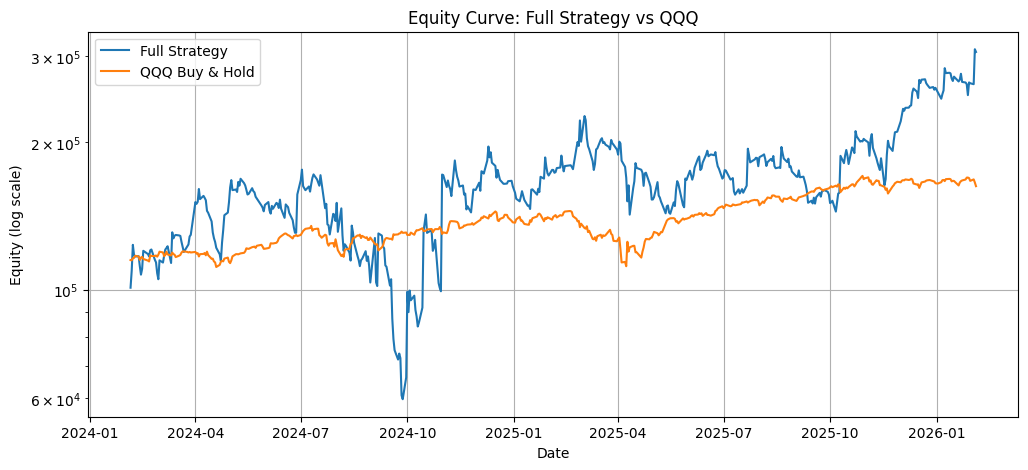

In [29]:
strategy_trades["net_pnl"].sum()
initial_capital = 100_000
strategy_daily = (strategy_trades.groupby("trading_day", as_index=False)["net_pnl"].sum().rename(columns={"net_pnl": "daily_pnl"}))
strategy_daily["trading_day"] = pd.to_datetime(strategy_daily["trading_day"])
strategy_daily = (strategy_daily.sort_values("trading_day").reset_index(drop=True))
strategy_daily["strategy_equity"] = (initial_capital + strategy_daily["daily_pnl"].cumsum())
strategy_daily["strategy_return"] = (strategy_daily["strategy_equity"].pct_change().fillna(0))
qqq_benchmark["trading_day"] = pd.to_datetime(qqq_benchmark["trading_day"])
comparison_df = strategy_daily.merge(qqq_benchmark[["trading_day", "benchmark_equity", "benchmark_return"]],on="trading_day",how="inner")

plt.figure(figsize=(12, 5))

plt.plot(comparison_df["trading_day"],comparison_df["strategy_equity"],label="Full Strategy")
plt.plot(comparison_df["trading_day"],comparison_df["benchmark_equity"],label="QQQ Buy & Hold")

plt.yscale("log")
plt.title("Equity Curve: Full Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Equity (log scale)")
plt.legend()
plt.grid(True)
plt.savefig("../results/equity_curve_full_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
def compute_drawdown(equity):
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown


def compute_performance_stats(
    equity,
    returns,
    bar_freq="D",
    periods_per_year=252,
):
    equity = equity.dropna()
    returns = returns.dropna()

    total_return = equity.iloc[-1] / equity.iloc[0] - 1

    n_periods = len(equity)
    years = n_periods / periods_per_year

    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1

    ann_vol = returns.std() * np.sqrt(periods_per_year)

    sharpe = (
        returns.mean() / returns.std() * np.sqrt(periods_per_year)
        if returns.std() != 0 else np.nan
    )

    downside_returns = returns[returns < 0]
    sortino = (
        returns.mean() / downside_returns.std() * np.sqrt(periods_per_year)
        if downside_returns.std() != 0 else np.nan
    )

    drawdown = compute_drawdown(equity)
    max_drawdown = drawdown.min()

    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return pd.Series({
        "CAGR": cagr,
        "Ann_Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Calmar": calmar,
        "Total_Return": total_return,
        "Max_Drawdown": max_drawdown,
        "Bar_Freq": bar_freq,
    })

In [31]:
# For a complete strategy vs QQQ:
performance_table = pd.DataFrame({
    "Full_Strategy": compute_performance_stats(
        equity=comparison_df["strategy_equity"],
        returns=comparison_df["strategy_return"],
    ),
    "QQQ_Buy_Hold": compute_performance_stats(
        equity=comparison_df["benchmark_equity"],
        returns=comparison_df["benchmark_return"],
    ),
})

performance_table

,Full_Strategy,QQQ_Buy_Hold
CAGR,0.744787,0.190709
Ann_Vol,1.093054,0.208822
Sharpe,0.98617,0.93654
Sortino,2.286,1.229275
Calmar,1.127887,0.834583
Total_Return,2.030864,0.415826
Max_Drawdown,-0.660338,-0.228508
Bar_Freq,D,D


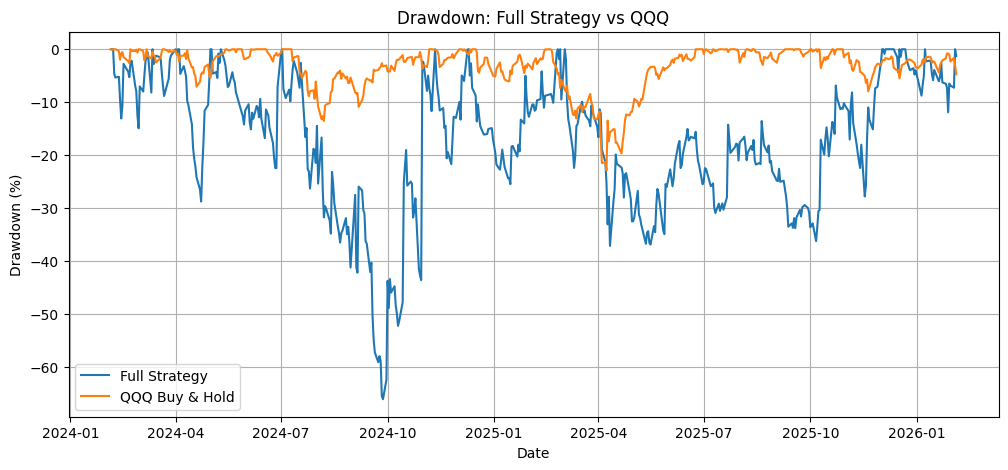

In [32]:
comparison_df["strategy_drawdown"] = compute_drawdown(
    comparison_df["strategy_equity"]
)

comparison_df["benchmark_drawdown"] = compute_drawdown(
    comparison_df["benchmark_equity"]
)

plt.figure(figsize=(12, 5))
plt.plot(
    comparison_df["trading_day"],
    comparison_df["strategy_drawdown"] * 100,
    label="Full Strategy"
)
plt.plot(
    comparison_df["trading_day"],
    comparison_df["benchmark_drawdown"] * 100,
    label="QQQ Buy & Hold"
)

plt.title("Drawdown: Full Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.savefig("../results/drawdown_full_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()